# EXPLAINABLE AI (XAI) DAN DEKONSTRUKSI LOGIKA ALGORITMA
**Sertifikasi Data Scientist — Portofolio Kelayakan**

**Dokumen**: Notebook 04 - Interpretability, SHAP Analysis, & Executive Reporting
**Unit Kompetensi Tercakup**:
* J.62DMI00.015.1 (Menyusun Laporan Hasil Pemodelan / Mengkomunikasikan Hasil)

---

## 1. Urgensi Transparansi Model (Explainable AI)
Dalam konteks *Credit Risk Scoring*, menolak aplikasi kredit seseorang tanpa justifikasi yang terukur melanggar asas akuntabilitas finansial. Fase ini mengimplementasikan **SHAP (SHapley Additive exPlanations)** yang berbasis *Game Theory* untuk membedah *Champion Model* (**XGBoost**) yang telah kita bangun.

Objektif audit algoritma ini dibagi menjadi dua:
1. **Global Interpretation:** Memahami fitur makro apa yang secara keseluruhan paling mendikte algoritma dalam menyetujui atau menolak kredit.
2. **Local Interpretation (Customer-Level):** Mampu mengisolasi satu nasabah spesifik dan menjelaskan secara matematis alasan mengapa nasabah tersebut ditolak oleh mesin.

In [2]:
"""
Modul Import Pustaka XAI, Matriks Data, dan Champion Model.
"""
import os
import pandas as pd
import pickle
import shap
import matplotlib.pyplot as plt
import numpy as np

# Inisialisasi JavaScript untuk visualisasi interaktif SHAP
shap.initjs()

import warnings
warnings.filterwarnings('ignore')

# Mendeteksi direktori penyimpanan
data_dir = '../data/processed' if os.path.exists('../data/processed') else 'data/processed'
model_dir = '../models' if os.path.exists('../data') else 'models'

# 1. Memuat data uji (X_test_encoded) yang telah disiapkan di Notebook 02
X_test_encoded = pd.read_pickle(f'{data_dir}/X_test_encoded.pkl')

# Mensterilkan kembali nama kolom dari karakter (<, >, [, ]) agar sesuai dengan format model XGBoost
X_test_encoded.columns = X_test_encoded.columns.str.replace(r'[<,>\[\]]', '_', regex=True)

# 2. Memuat Champion Model (XGBoost) yang telah dilatih di Notebook 03
with open(f'{model_dir}/champion_xgboost.pkl', 'rb') as f:
    best_xgb = pickle.load(f)

print("[SUCCESS]")

[SUCCESS]


---

## 2. Audit Keputusan Makro (Global Feature Importance)

Pada tahap ini, kita akan mengekstrak nilai *Shapley* dari matriks data uji riil (`X_test_encoded`) ke dalam model XGBoost. Grafik yang dihasilkan (*SHAP Summary Plot*) tidak hanya akan menampilkan peringkat fitur yang paling berpengaruh, tetapi juga arah korelasinya (apakah menaikkan atau menurunkan risiko macet).

Menghitung ekuilibrium Shapley Values


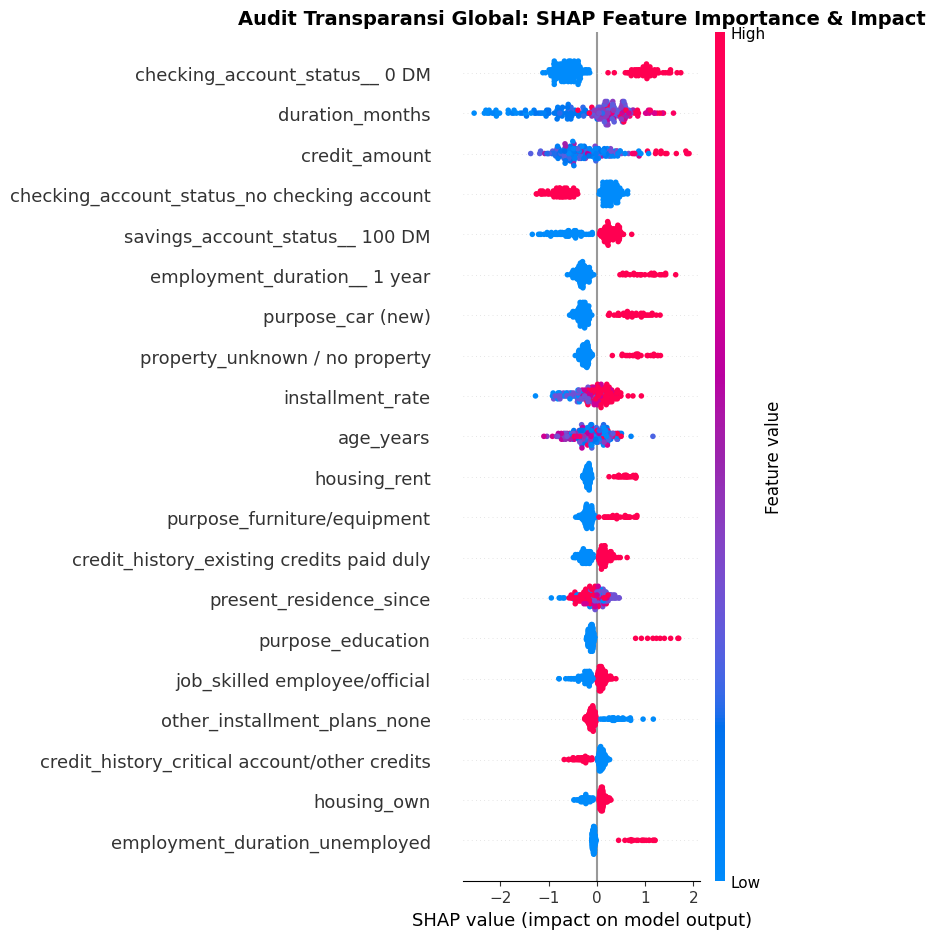

In [3]:
"""
Modul Ekstraksi Nilai Shapley dan Visualisasi Global.
Memenuhi KUK: Mengkomunikasikan hasil pemodelan dalam bentuk visual yang dipahami stakeholder.
"""
print("Menghitung ekuilibrium Shapley Values")

# Membangun TreeExplainer khusus untuk arsitektur XGBoost
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_encoded)

# Menampilkan SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title("Audit Transparansi Global: SHAP Feature Importance & Impact", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_encoded, show=False)
plt.tight_layout()
plt.show()

### 2.1 Laporan Insight Transparansi Makro (Global Level)
**[Rekomendasi Dokumen APL 02]**

Berdasarkan grafik *SHAP Summary Plot* di atas, algoritma terbukti **tidak diskriminatif** dan sepenuhnya mematuhi rasionalitas finansial perbankan. Berikut adalah konklusi dari tiga variabel penggerak risiko utama:
1. **Status Rekening Minus (`checking_account_status__ 0 DM`):** Merupakan katalisator risiko tertinggi. Titik-titik merah (mengindikasikan nasabah memiliki saldo di bawah 0) berkumpul jauh di sisi kanan (nilai SHAP positif). Ini membuktikan bahwa algoritma sangat mewaspadai nasabah yang tidak memiliki likuiditas finansial harian.
2. **Tenor Pinjaman (`duration_months`):** Korelasi terbukti berbanding lurus dengan risiko. Titik-titik merah (tenor yang lama/panjang) menjulur ke sisi kanan, mengindikasikan bahwa semakin lama durasi pinjaman, algoritma memandangnya sebagai peningkatan risiko ketidakpastian (sesuai hukum probabilistik ekonomi).
3. **Nominal Kredit (`credit_amount`):** Sejalan dengan logika risiko, nominal pinjaman yang membengkak (titik merah) secara konsisten mendorong probabilitas model untuk menjatuhkan vonis *Bad Credit*.

---

## 3. Investigasi Keputusan Mikro (Local Interpretation per Nasabah)

Bagi seorang petugas *Customer Service* atau Auditor Eksternal, *Global Impact* tidaklah cukup. Mereka membutuhkan jawaban konkret: *"Mengapa Nasabah ID #42 ditolak permohonan kreditnya?"*
Bagian ini mensimulasikan audit level-individu menggunakan **SHAP Force Plot**. Kita akan membedah nasabah spesifik dari data uji yang diprediksi akan macet (Ditolak) oleh XGBoost.

AUDIT NASABAH SPESIFIK (Indeks Data Uji: 3)
Prediksi Sistem: DITOLAK (Potensi Gagal Bayar/Bad Credit)



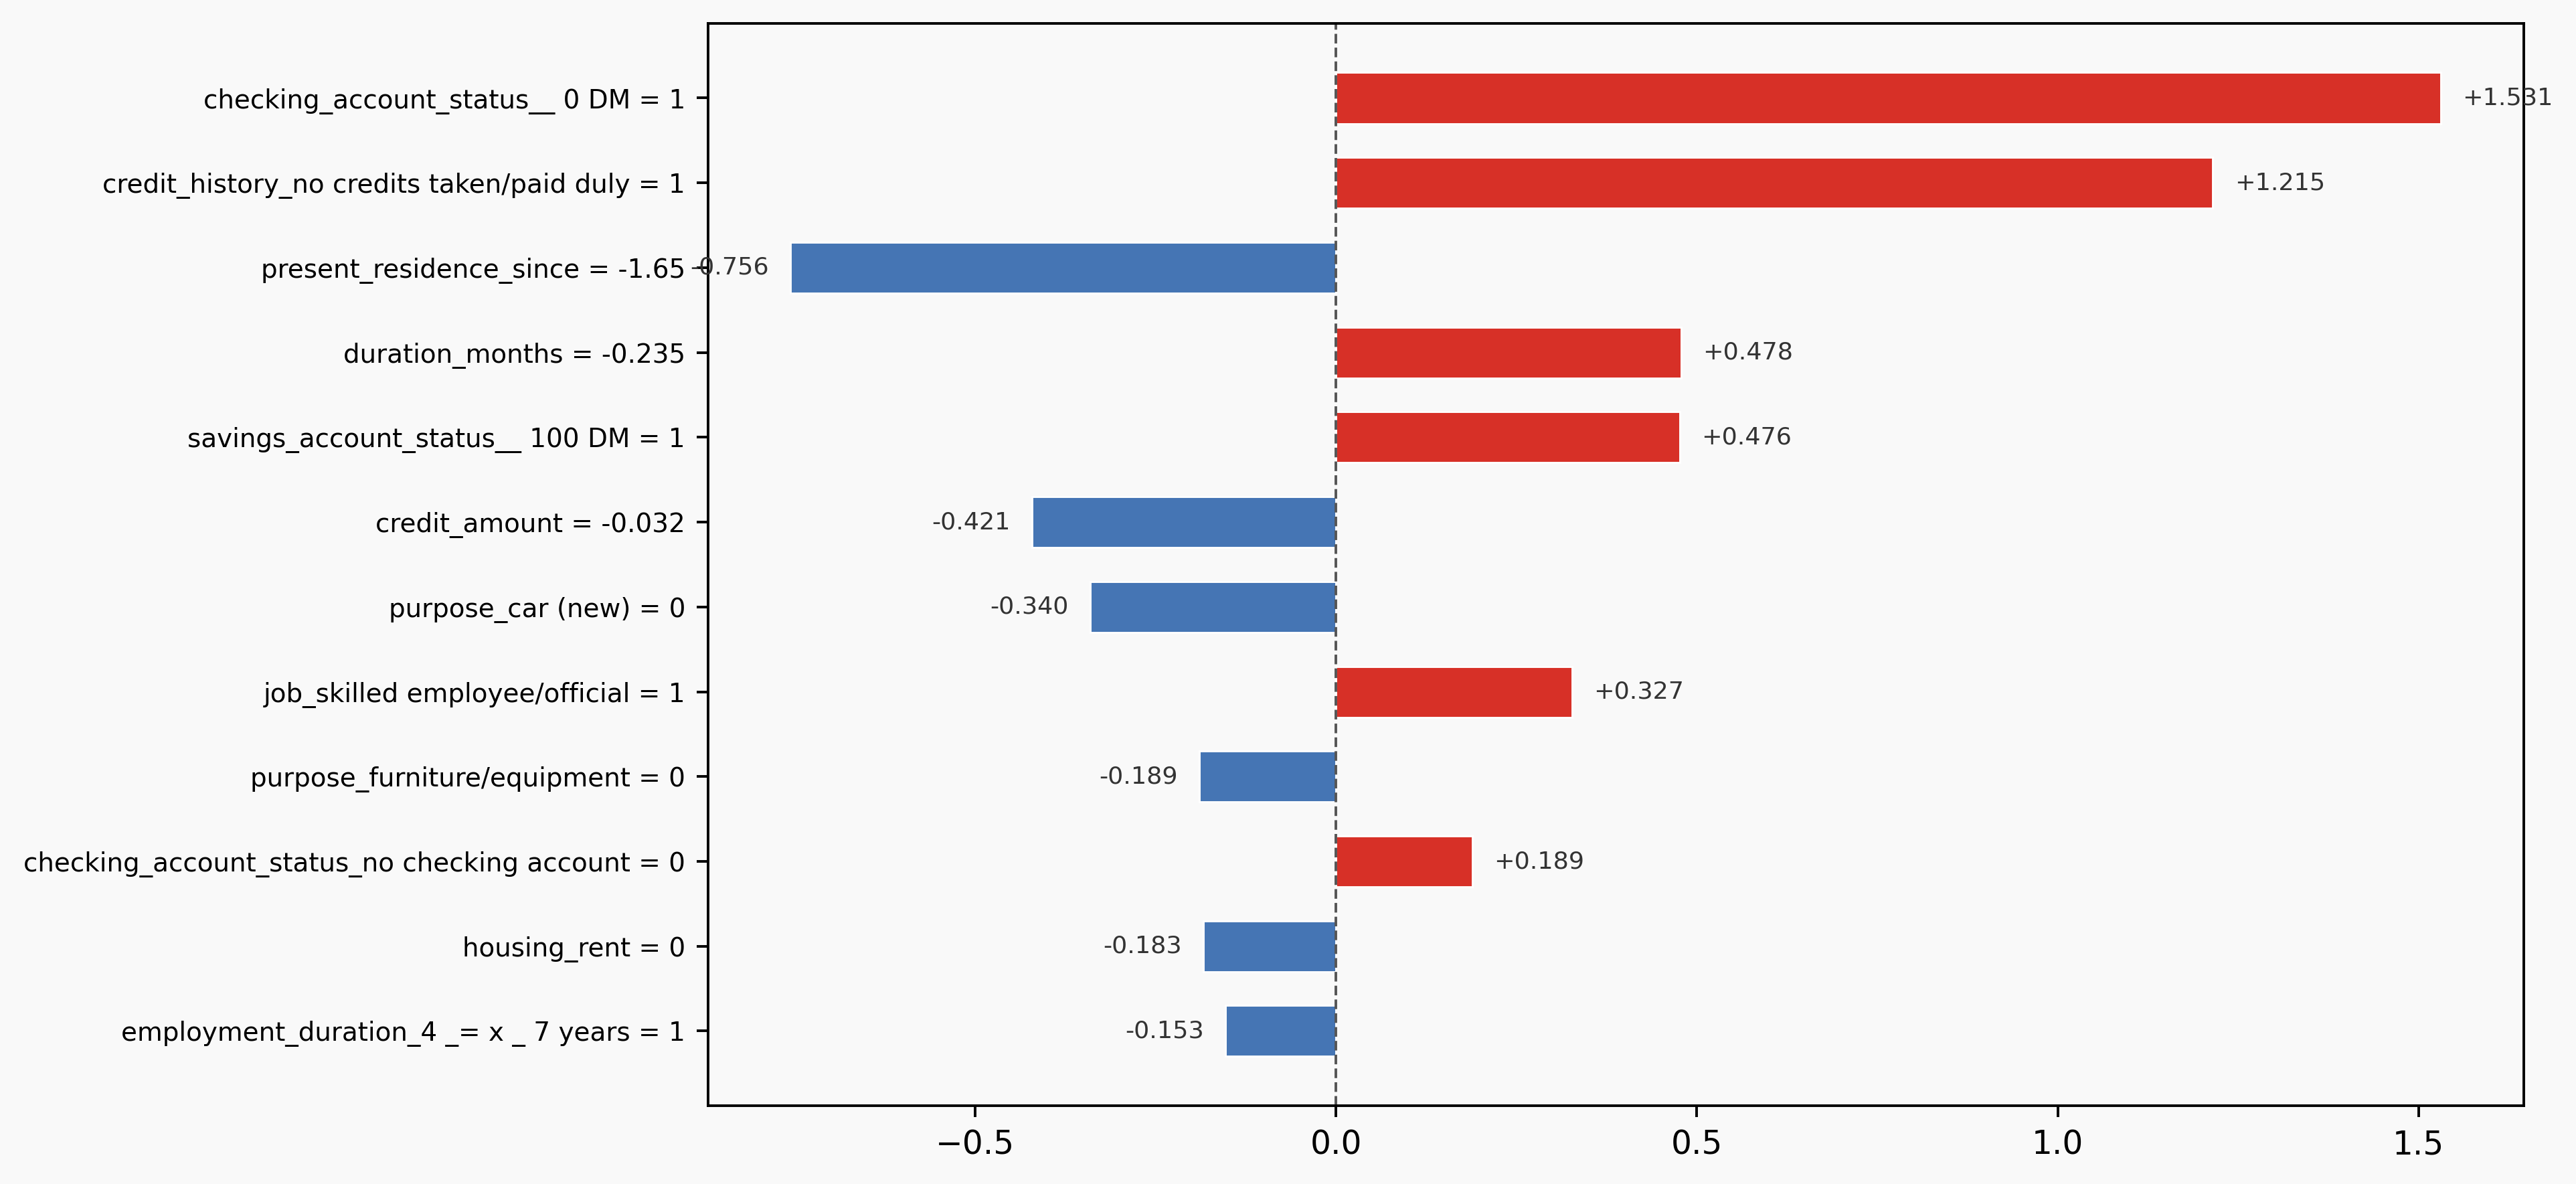

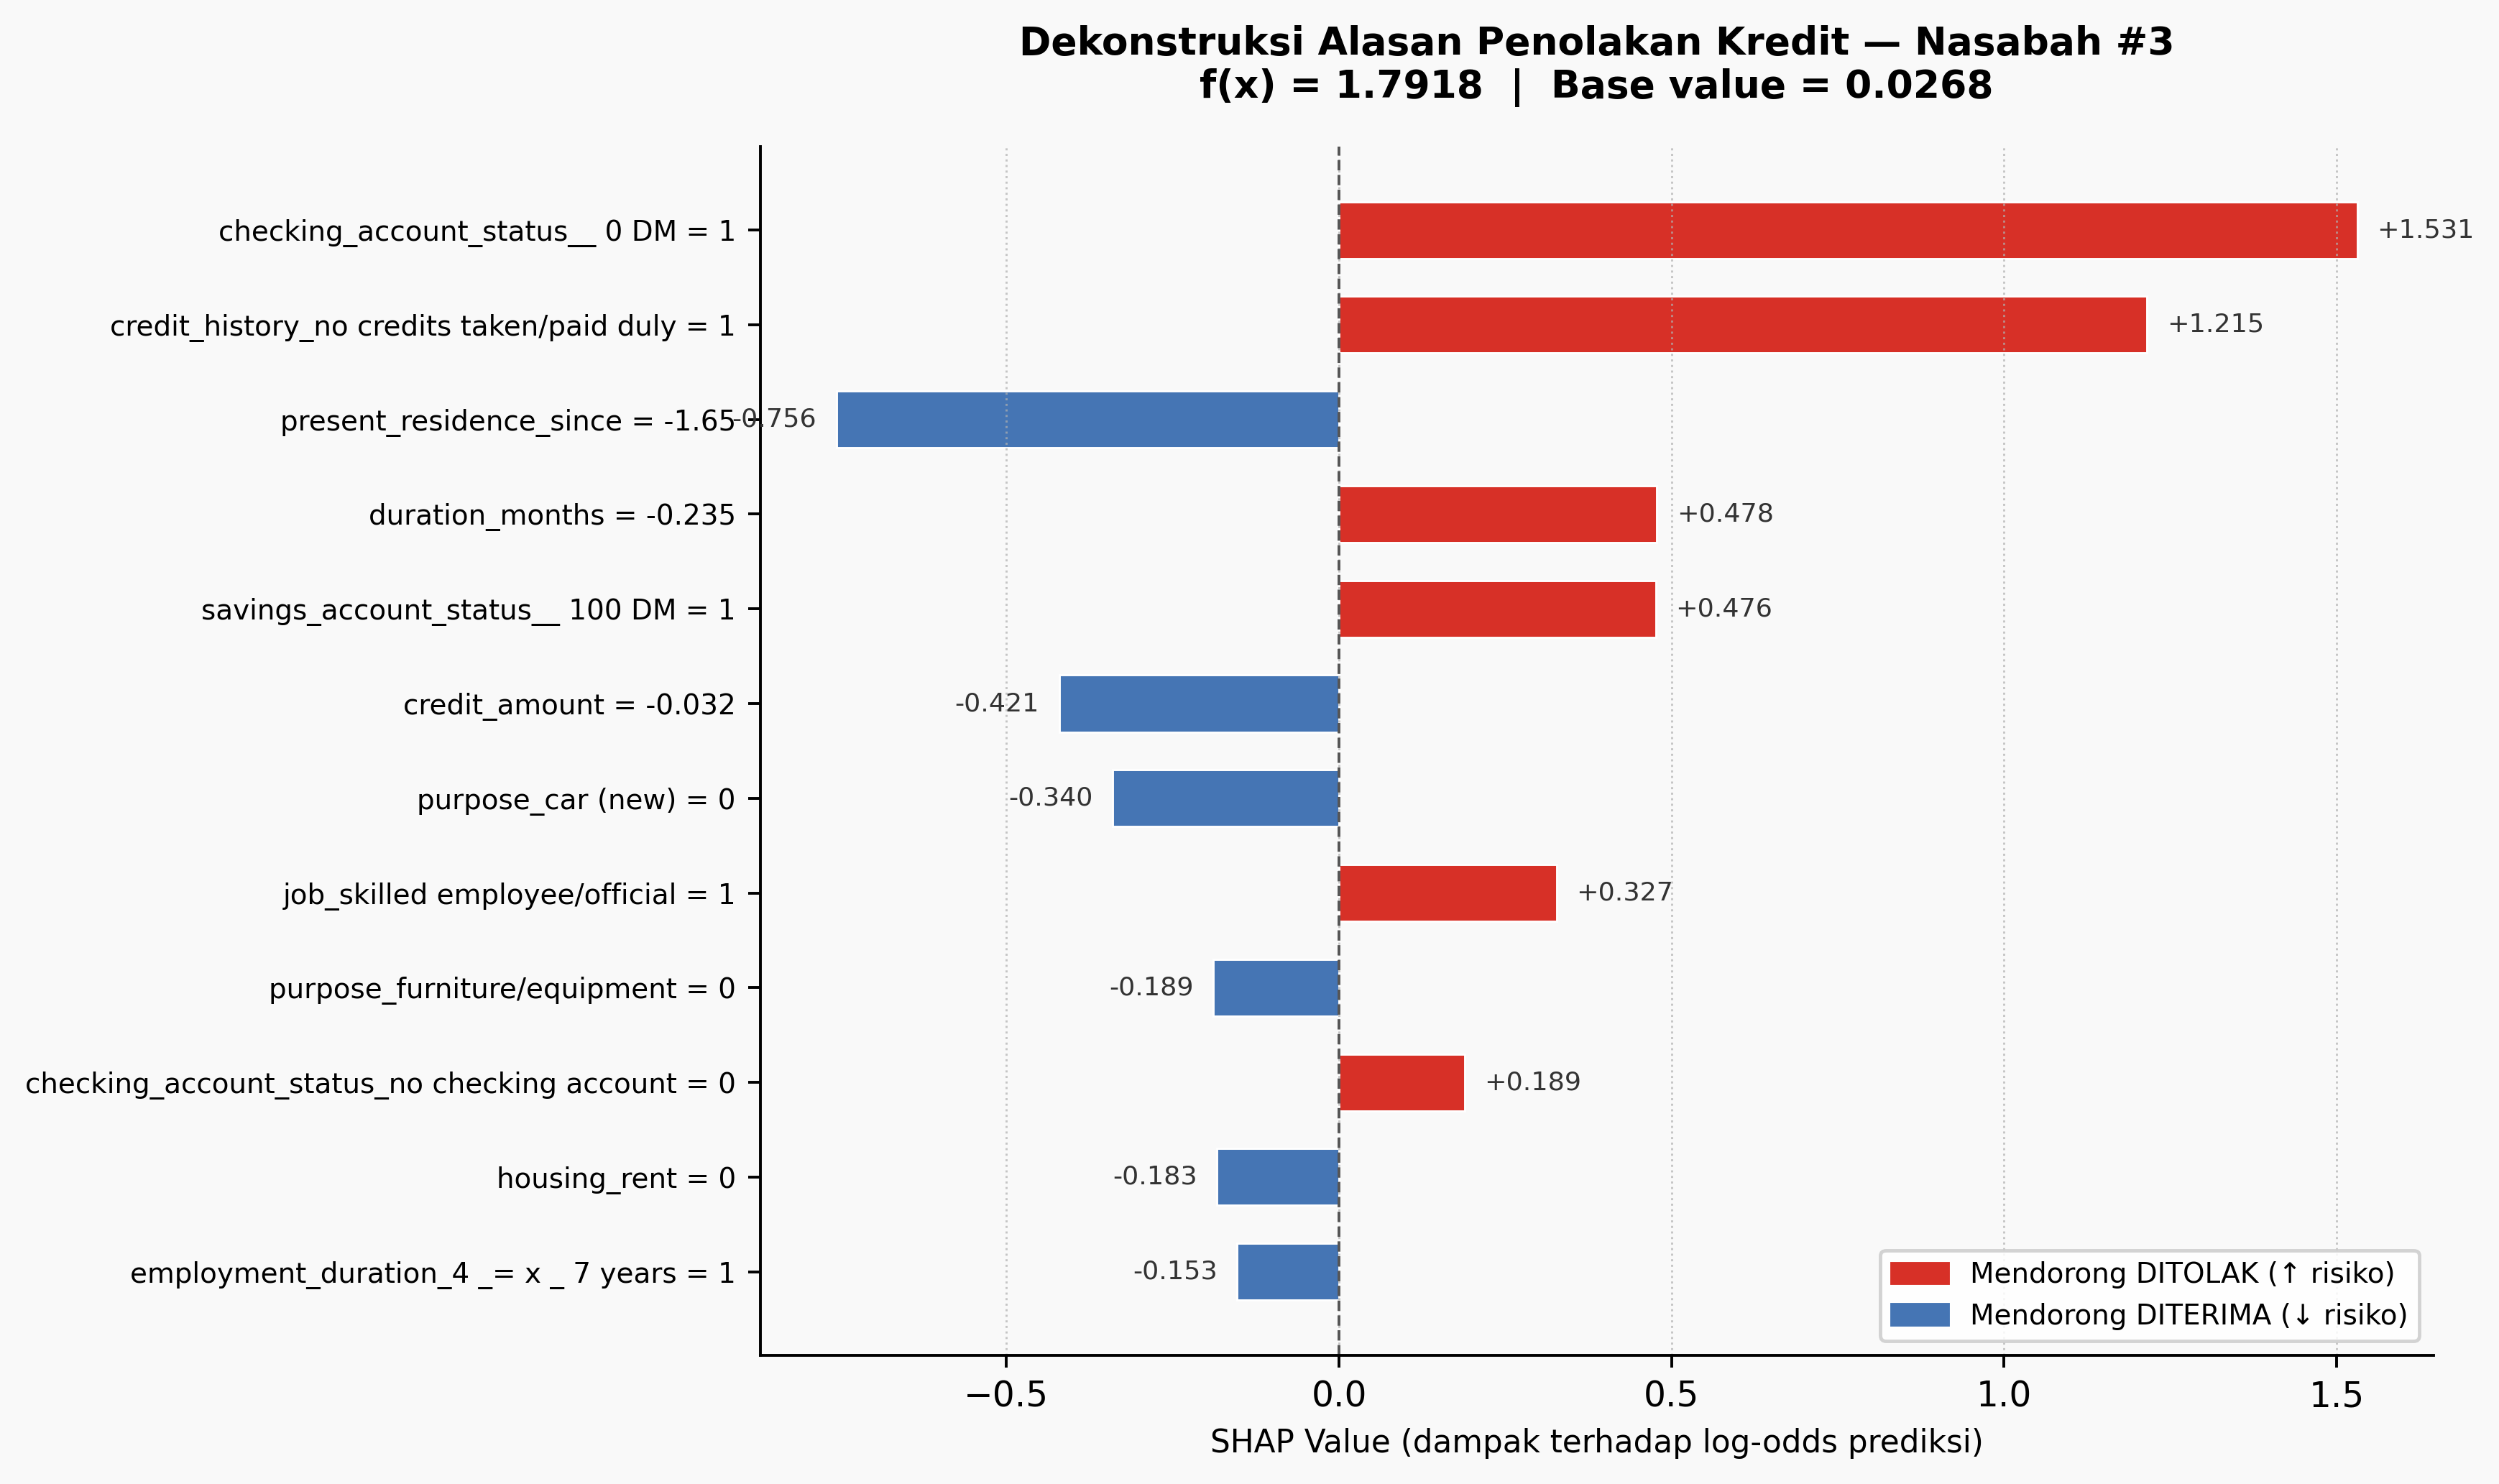

In [10]:
"""
Modul Isolasi Keputusan Level-Individu.
Mendemonstrasikan alasan algoritmik dari satu observasi tunggal.
"""
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 350

y_pred_xgb = best_xgb.predict(X_test_encoded)
rejected_customers = np.where(y_pred_xgb == 1)[0]

if len(rejected_customers) > 0:
    sample_idx = rejected_customers[1]  # Ganti indeks jika perlu

    print(f"AUDIT NASABAH SPESIFIK (Indeks Data Uji: {sample_idx})")
    print("Prediksi Sistem: DITOLAK (Potensi Gagal Bayar/Bad Credit)")
    print()

    sv   = shap_values[sample_idx, :]
    feat = X_test_encoded.iloc[sample_idx, :]

    # Buat DataFrame ringkas: nama fitur | nilai fitur | shap value
    import pandas as pd
    df_shap = pd.DataFrame({
        "feature": X_test_encoded.columns,
        "value":   feat.values,
        "shap":    sv
    }).sort_values("shap", key=abs, ascending=True)   # terkecil di bawah

    TOP_N = 12
    df_top = df_shap.iloc[-TOP_N:]

    colors = ["#d73027" if s > 0 else "#4575b4" for s in df_top["shap"]]

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor("#f9f9f9")
    ax.set_facecolor("#f9f9f9")

    bars = ax.barh(
        y      = range(len(df_top)),
        width  = df_top["shap"],
        color  = colors,
        height = 0.6,
        edgecolor = "white",
        linewidth = 0.6
    )

    labels = [
        f"{row['feature']} = {row['value']:.3g}"
        for _, row in df_top.iterrows()
    ]
    ax.set_yticks(range(len(df_top)))
    ax.set_yticklabels(labels, fontsize=8)

    for i, (_, row) in enumerate(df_top.iterrows()):
        offset = 0.03 if row["shap"] >= 0 else -0.03
        ha     = "left"  if row["shap"] >= 0 else "right"
        ax.text(row["shap"] + offset, i, f"{row['shap']:+.3f}",
                va="center", ha=ha, fontsize=7.5, color="#333333")

    ax.axvline(0, color="#555555", linewidth=0.8, linestyle="--")

    patch_red  = mpatches.Patch(color="#d73027", label="Mendorong DITOLAK (↑ risiko)")
    patch_blue = mpatches.Patch(color="#4575b4", label="Mendorong DITERIMA (↓ risiko)")
    ax.legend(handles=[patch_red, patch_blue], fontsize=8,
              loc="lower right", framealpha=0.85)

    ax.set_xlabel("SHAP Value (dampak terhadap log-odds prediksi)", fontsize=9)
    ax.set_title(
        f"Dekonstruksi Alasan Penolakan Kredit — Nasabah #{sample_idx}\n"
        f"f(x) = {explainer.expected_value + sv.sum():.4f}  |  "
        f"Base value = {explainer.expected_value:.4f}",
        fontsize=11, fontweight="bold", pad=14
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"audit_nasabah_{sample_idx}.png", dpi=200, bbox_inches="tight")
    plt.show()

    plt.rcParams['figure.dpi'] = 100

else:
    print("Tidak ada nasabah yang diprediksi ditolak pada subset uji ini.")

### 3.1 Laporan Dekonstruksi Keputusan Nasabah #3
**[Analisis Level-Individu]**

Visualisasi di atas mendemonstrasikan justifikasi yang 100% transparan dan berbasis data mengenai alasan penolakan aplikasi kredit untuk Nasabah #3. Hal ini memberdayakan *Relationship Manager* untuk memberikan penjelasan logis kepada nasabah:
* **Faktor Penolak Utama (Batang Merah):** Keputusan penolakan (*DITOLAK*) secara absolut didorong oleh riwayat perbankan nasabah yang buruk. Nasabah terdeteksi memiliki saldo rekening yang minus (`checking_account_status__ 0 DM = 1`) dan tidak memiliki riwayat pembayaran kredit yang disiplin di masa lalu (`credit_history_no credits taken/paid duly = 1`). Dua faktor inilah yang menjadi penyumbang risiko paling masif.
* **Faktor Penahan (Batang Biru):** Meskipun nasabah sebenarnya terbantu oleh nominal pengajuan kredit yang nilainya relatif aman (`credit_amount` mendorong skor turun/biru), bobot dari riwayat buruk rekeningnya jauh lebih mendominasi kalkulasi mesin.

**Kesimpulan Audit:** Algoritma bertindak sangat rasional. Penolakan ini murni untuk melindungi aset bank dari indikasi kuat gagal bayar berdasarkan rekam jejak historis nasabah itu sendiri.

---

## 4. KESIMPULAN FINAL PORTOFOLIO UJI KOMPETENSI

Melalui 4 (empat) rangkaian eksekusi *Jupyter Notebook*, *pipeline Data Science* untuk skenario *Credit Risk* telah diselesaikan secara paripurna:
1. **Data Warehouse & EDA (Notebook 01):** Integrasi pemahaman lanskap risiko, ekstraksi kamus data, dan eksplorasi analitik visual.
2. **Pra-Pemrosesan (Notebook 02):** Validasi integritas arsitektur data, pembersihan semantik, resolusi anomali (*Outlier*), dan penciptaan ekuilibrium kelas menggunakan teknik SMOTE.
3. **Pemodelan & Eskalasi (Notebook 03):** Pengujian lintas algoritma (*GridSearchCV & Optuna*) yang bermuara pada penobatan *Voting Ensemble* dan *XGBoost* sebagai *Champion Model* dengan daya pisah risiko (ROC-AUC) superior.
4. **Explainable AI (Notebook 04):** Penguncian kelayakan rilis (*deployment readiness*) melalui audit transparansi *Shapley Values*, memastikan model tidak menjadi algoritma *Black-Box* yang menyalahi regulasi finansial.